KABUNGA AKRAM JOSHUA: M25B38/004
ABI MIREMBE KIGOZI:M25B38/022
MATTHEW KIWUMULO KYANJO:M25B38/011
KIBIRIGE SAMUEL LUTWAMA:M25B38/034
NAMANYA BRENDA HANNAH:M25B38/043

DATAMINING AND WRANGLING ASSIGNMENT
DATASET CHOSEN: RICE PRICE DATASET
SOURCE: KAGGLE
LINK TO SOURCE:https://www.kaggle.com/datasets/abhishekkaggle8585/rice-price-dirty-dataset


WHY WE CHOSE IT?
It contains a rich mix of categorical and numerical fields item type, payment method, location, quantity, price, and total spend which makes it possible to answer practical business questions such as which items sell the most to guide restocking.
Which sell the least to reduce unnecessary purchasing, which payment methods and locations customers prefer, and how sales trends change over time.
The dataset also has values missing in every column as a realistic mix of missing values for example, Location is missing or invalid in many of rows, and Payment Method as well.
This makes the dataset well-suited not just for analysis, but for practicing realworld data cleaning skills    
STRUCTURE:
It has 8 columns and 10,000 rows. A single row represents one transaction with the transaction ID, Item Bought, Payment method, price per unit(USD), total spent(USD),Location,Quantity and the transaction Date.
The rows carry both numerical and categorical data such as money, dates and types of transaction methods used.

In [7]:
import pandas as pd
from pandas import Series, DataFrame
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler ## so that our variables with differenct scales can appera on the same plotline
import numpy as np

In [8]:
file= pd.read_csv("C:/Users/user/Documents/cafe sales/dirty_cafe_sales.csv")#to fetch the downloaded dataset

pd.set_option("display.max_rows",10001)#this displays the rows of the dataset. All 10001
pd.set_option("display.float_format", "{:.1f}".format)#this set the number of decimal places to one.
print(file)

     Transaction ID      Item Quantity Price Per Unit Total Spent  \
0       TXN_1961373    Coffee        2            2.0         4.0   
1       TXN_4977031      Cake        4            3.0        12.0   
2       TXN_4271903    Cookie        4            1.0       ERROR   
3       TXN_7034554     Salad        2            5.0        10.0   
4       TXN_3160411    Coffee        2            2.0         4.0   
5       TXN_2602893  Smoothie        5            4.0        20.0   
6       TXN_4433211   UNKNOWN        3            3.0         9.0   
7       TXN_6699534  Sandwich        4            4.0        16.0   
8       TXN_4717867       NaN        5            3.0        15.0   
9       TXN_2064365  Sandwich        5            4.0        20.0   
10      TXN_2548360     Salad        5            5.0        25.0   
11      TXN_3051279  Sandwich        2            4.0         8.0   
12      TXN_7619095  Sandwich        2            4.0         8.0   
13      TXN_9437049    Cookie     

In [9]:
file.isnull().sum()#this is to help us show how many missing values per column.
#On this stage, we asked ourselves what we wanted our data to communicate or answer which would help us tackle cleaning data the right way.
#Since we are looking to answer a question about restocking and service provision, we are going to focus on item purchase, quantity, price and unit. 


Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [10]:
#dropping the location and transaction date column
file = file.drop(columns=["Location", "Transaction Date"])
print(file)

     Transaction ID      Item Quantity Price Per Unit Total Spent  \
0       TXN_1961373    Coffee        2            2.0         4.0   
1       TXN_4977031      Cake        4            3.0        12.0   
2       TXN_4271903    Cookie        4            1.0       ERROR   
3       TXN_7034554     Salad        2            5.0        10.0   
4       TXN_3160411    Coffee        2            2.0         4.0   
5       TXN_2602893  Smoothie        5            4.0        20.0   
6       TXN_4433211   UNKNOWN        3            3.0         9.0   
7       TXN_6699534  Sandwich        4            4.0        16.0   
8       TXN_4717867       NaN        5            3.0        15.0   
9       TXN_2064365  Sandwich        5            4.0        20.0   
10      TXN_2548360     Salad        5            5.0        25.0   
11      TXN_3051279  Sandwich        2            4.0         8.0   
12      TXN_7619095  Sandwich        2            4.0         8.0   
13      TXN_9437049    Cookie     

In [12]:
#Fixing the missing totals for the items
for col in ["Quantity","Price Per Unit", "Total Spent"]:
    file[col] =pd.to_numeric(file[col],errors="coerce")
#In the above step we forcefully changed the descriptive values to NaN
#To have the total spent for the items as long as the item, price and quantity available
mask =file["Total Spent"].isna()
file.loc[mask,"Total Spent"] = file.loc[mask, "Quantity"] * file.loc[mask, "Price Per Unit"]
#this checks how many are still missing in Qunatity
print(file["Total Spent"].isna().sum())
print(file)

40
     Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
2       TXN_4271903    Cookie       4.0             1.0          4.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
5       TXN_2602893  Smoothie       5.0             4.0         20.0   
6       TXN_4433211   UNKNOWN       3.0             3.0          9.0   
7       TXN_6699534  Sandwich       4.0             4.0         16.0   
8       TXN_4717867       NaN       5.0             3.0         15.0   
9       TXN_2064365  Sandwich       5.0             4.0         20.0   
10      TXN_2548360     Salad       5.0             5.0         25.0   
11      TXN_3051279  Sandwich       2.0             4.0          8.0   
12      TXN_7619095  Sandwich       2.0             4.0      

In [17]:
#Getting rid of the unkown or NaN Item rows since they do not help in our analysis
file["Item"] = file["Item"].replace(["ERROR", "UNKNOWN", "",""], np.nan)
#Dropping all the rows where Item is NaN
file=file.dropna(subset=["Item"])
print(file.shape) #shows how many we have dropped and how many rows are left
print(file) 

(9031, 6)
     Transaction ID      Item  Quantity  Price Per Unit  Total Spent  \
0       TXN_1961373    Coffee       2.0             2.0          4.0   
1       TXN_4977031      Cake       4.0             3.0         12.0   
2       TXN_4271903    Cookie       4.0             1.0          4.0   
3       TXN_7034554     Salad       2.0             5.0         10.0   
4       TXN_3160411    Coffee       2.0             2.0          4.0   
5       TXN_2602893  Smoothie       5.0             4.0         20.0   
7       TXN_6699534  Sandwich       4.0             4.0         16.0   
9       TXN_2064365  Sandwich       5.0             4.0         20.0   
10      TXN_2548360     Salad       5.0             5.0         25.0   
11      TXN_3051279  Sandwich       2.0             4.0          8.0   
12      TXN_7619095  Sandwich       2.0             4.0          8.0   
13      TXN_9437049    Cookie       5.0             1.0          5.0   
15      TXN_2847255     Salad       3.0             5.

In [19]:
item_summary = file.groupby("Item").agg({"Quantity": "sum","Total Spent": "sum"}).sort_values("Total Spent", ascending=False)
print(item_summary)
#To find the total price paid for each item and the total quatity 

          Quantity  Total Spent
Item                           
Salad       3310.0      17320.0
Sandwich    3245.0      13664.0
Smoothie    3221.0      13320.0
Juice       3373.0      10509.0
Cake        3329.0      10395.0
Coffee      3368.0       7062.0
Tea         3154.0       4951.5
Cookie      3090.0       3223.0


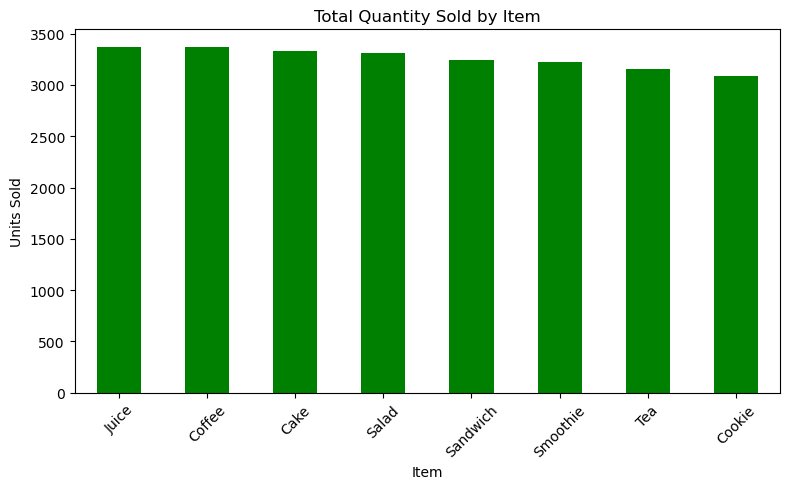

In [22]:
#Visaulizig the above data
item_quantities = file.groupby("Item")["Quantity"].sum().sort_values(ascending=False)

item_quantities.plot(kind="bar", figsize=(8,5), color="green")
plt.title("Total Quantity Sold by Item")
plt.ylabel("Units Sold")
plt.xlabel("Item")
plt.xticks(rotation=45)
plt.tight_layout() ##adjusts the spacing for the labels or titles to fit on the chart well
plt.show()

The graph shows the Items and the units sold. The items' sales are all fairly or roughly close to one another and therefore shows that demand is relatively the same. From this graph it is safe to say that all the items can all be restocked at the same rate due to similar demand. It also tells us that cookies are the safest item to remove from the menu and use that purchasing power for other items. Juice and coffee should be prioritised. Had time of purchase been available, we would be able to prove that the rush hours are during morning or lunch since coffee and juice are drinks for such times as well as days with most traffic for promotions.

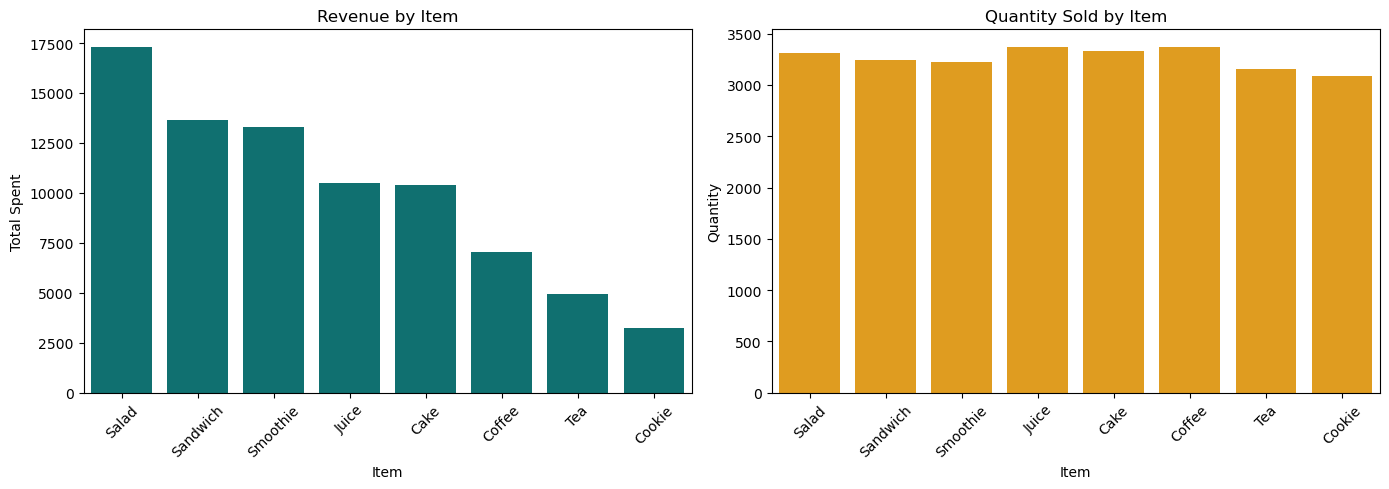

In [23]:
import seaborn as sns #A library for visualisation

item_summary = file.groupby("Item").agg({"Quantity": "sum","Total Spent": "sum"}).sort_values("Total Spent", ascending=False).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(data=item_summary, x="Item", y="Total Spent", ax=axes[0], color="teal")
axes[0].set_title("Revenue by Item")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=item_summary, x="Item", y="Quantity", ax=axes[1], color="orange")
axes[1].set_title("Quantity Sold by Item")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

From the graphs above, we see that salads are the most profitable amongst the items even if they are not the most selling. This is because the salad is more expensive per unit and people still want them. WHich gives it restocking priority.

REALTIONSHIP
1. In the first two graphs we categorsied the categorical with the numerical. This helps us easily answer the questions on rstocking by seeing which item drives more profit/revenue and volume.
2. The second grouping we carried out we used categorical vs categorical. This helps to reveal whether certain items are bought differently do people pay cash for cheap items but use cards for pricier ones. Useful for payment infrastructure decisions like does the cafe need more card readers near certain counters?

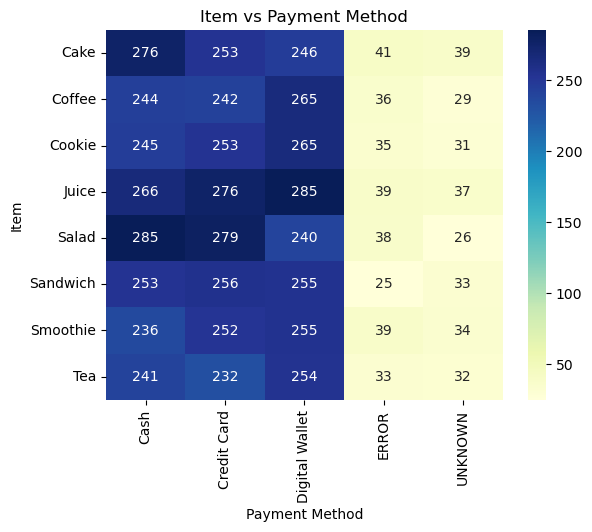

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

crosstab = pd.crosstab(file["Item"], file["Payment Method"])
sns.heatmap(crosstab, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Item vs Payment Method")
plt.show()